<a href="https://colab.research.google.com/github/Sulayman98/MSc-Data-Science-Project-2/blob/main/Data_Science_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.0 Introduction**

Returns in the stock market can be a means to accumulate wealth, providing an alternative income source to wages. Given the importance of the stock market, this project aims to provide insights into both industry players and individuals who are aiming to build wealth through the Malaysian stock market.

For this project, five datasets will be analyzed to extract valuable insights through descriptive statistical methods and visualizations. The datasets include:
1. Population: State-level population data from 1970 to 2024, categorized by sex, age group, and
ethnicity.
2. Basic Amenities: Proportion of households with access to essential amenities, such as electricity,
piped water, and sanitary latrines, by state and district.
3. Profile: Number of households and living quarters by state, spanning from 1970 to 2024.
4. Agriculture: Production and planted areas of crops from 2017 to 2022.
5. Kuala Lumpur Stock Exchange (KLSE): Time series data on Malaysian stock market data represented by the KLSE index, including subcomponents
6. CBOE Volatility Index (VIX): To measure uncertainty

# **2.0 Data Collection and Data Wrangling**

Datasets were obtained from open sources such as Investing.com for KLSE data. This includes cyclical sub-indices such as KLTE (KL Technology Index), KLEN (KL Energy Index) and KLFIN (KL Finance Index) as well as defensive sub-indices such as KLCM (KL Consumer Product)

#Links to dataset

1. KLSE https://www.investing.com/indices/ftse-malaysia-klci-historical-data
2. KLFIN https://www.investing.com/indices/kl-finance-historical-data
3. KLTE https://www.investing.com/indices/kl-technology
4. KLCP https://www.investing.com/indices/kl-consumer-product-historical-data
5. VIX https://www.investing.com/indices/volatility-s-p-500-historical-data

In [ ]:
#Part 1: Loading relevant datasets

import pandas as pd
from datetime import datetime
from google.colab import files
uploaded = files.upload() #Uploading files to the cloud

dataframe = {
    "klse": pd.read_csv("/content/FTSE Malaysia KLCI Historical Data.csv"),
    "klfin": pd.read_csv("/content/KL Finance Historical Data.csv"),
    "klte": pd.read_csv("/content/KL Technology Historical Data.csv"),
    "klcp": pd.read_csv("/content/KL Consumer Product Historical Data.csv"),
    "vix": pd.read_csv("/content/CBOE Volatility Index Historical Data.csv")
}

dataframe["klse"].head()


,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"1,683.63","1,688.18","1,698.53","1,672.74",5.21B,0.03%
1,05/01/2026,"1,683.07","1,728.74","1,768.46","1,680.59",6.12B,-2.26%
2,04/01/2026,"1,722.02","1,715.94","1,733.84","1,673.14",5.84B,1.87%
3,03/01/2026,"1,690.36","1,688.64","1,737.12","1,664.07",6.98B,-1.53%
4,02/01/2026,"1,716.61","1,756.09","1,761.57","1,714.09",4.65B,-1.39%


# 2.1 Understanding the data structure

Within this dataframe, for each of the variables klse, klfin, klte, klcp and vix, there are 258 rows which represents the monthly data from January 2005 until June 2026, and 7 columns containing:

1. Date: The month of trading
2. Price: The closing price for the month
3. Open: Opening price for the month
4. High: Highest price during the month
5. Low: Lowest price during the month
6. Volume: Number of shares traded during the month
7. Change %: Percentage share from previous month's closing position

All of these data are classified as objects. For analysis preparation, they will be wrangled into 'float'.

In [ ]:
# Structure of the dataframes
for name, df in dataframe.items():
    print(f"=== {name} ===")
    print(df.info())
    print()

=== klse ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      258 non-null    object
 1   Price     258 non-null    object
 2   Open      258 non-null    object
 3   High      258 non-null    object
 4   Low       258 non-null    object
 5   Vol.      258 non-null    object
 6   Change %  258 non-null    object
dtypes: object(7)
memory usage: 14.2+ KB
None

=== klfin ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      258 non-null    object
 1   Price     258 non-null    object
 2   Open      258 non-null    object
 3   High      258 non-null    object
 4   Low       258 non-null    object
 5   Vol.      258 non-null    object
 6   Change %  258 non-null    object
dtypes: object(7)
memory usage: 14

In [ ]:
#Identifying number of rows and columns in dataframe
print('The number of rows and columns in dataframe:', df.info)

The number of rows and columns in dataframe: <bound method DataFrame.info of            Date  Price   Open   High    Low  Vol. Change %
0    06/01/2026  18.81  15.88  23.34  15.18   NaN   22.78%
1    05/01/2026  15.32  17.01  19.44  15.22   NaN   -9.30%
2    04/01/2026  16.89  24.30  28.00  16.87   NaN  -33.11%
3    03/01/2026  25.25  24.66  35.30  20.28   NaN   27.14%
4    02/01/2026  19.86  19.95  23.10  16.05   NaN   13.88%
..          ...    ...    ...    ...    ...   ...      ...
253  05/01/2005  13.29  15.45  17.70  11.65   NaN  -13.19%
254  04/01/2005  15.31  13.64  18.59  11.20   NaN    9.20%
255  03/01/2005  14.02  11.95  14.89  11.66   NaN   16.06%
256  02/01/2005  12.08  12.80  13.20  10.90   NaN   -5.77%
257  01/01/2005  12.82  13.39  14.75  12.29   NaN   -3.54%

[258 rows x 7 columns]>


# 2.2 Cleaning the data

In [ ]:
dataframe["klse"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"1,683.63","1,688.18","1,698.53","1,672.74",5.21B,0.03%
1,05/01/2026,"1,683.07","1,728.74","1,768.46","1,680.59",6.12B,-2.26%
2,04/01/2026,"1,722.02","1,715.94","1,733.84","1,673.14",5.84B,1.87%
3,03/01/2026,"1,690.36","1,688.64","1,737.12","1,664.07",6.98B,-1.53%
4,02/01/2026,"1,716.61","1,756.09","1,761.57","1,714.09",4.65B,-1.39%


In [ ]:
dataframe["klfin"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,"19,644.36","19,600.37","19,841.40","19,321.03",1.25B,0.61%
1,05/01/2026,"19,524.29","19,936.86","20,597.81","19,486.00",1.59B,-1.81%
2,04/01/2026,"19,885.03","20,318.16","20,545.36","19,489.26",1.67B,-0.69%
3,03/01/2026,"20,023.99","20,715.43","21,058.58","19,765.68",2.31B,-5.02%
4,02/01/2026,"21,081.80","21,604.45","21,924.71","21,058.15",2.01B,-1.99%


In [ ]:
dataframe["klte"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,71.48,73.12,74.67,69.29,4.72B,-3.24%
1,05/01/2026,73.87,62.56,73.87,62.56,6.73B,18.99%
2,04/01/2026,62.08,51.56,64.56,50.98,5.85B,22.91%
3,03/01/2026,50.51,54.32,55.31,50.21,3.74B,-9.59%
4,02/01/2026,55.87,56.26,57.01,52.72,3.84B,-0.64%


In [ ]:
dataframe["klcp"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,486.47,485.49,491.49,482.53,3.11B,-0.23%
1,05/01/2026,487.57,518.51,519.94,483.45,4.67B,-5.89%
2,04/01/2026,518.11,508.65,522.87,498.67,4.62B,2.69%
3,03/01/2026,504.52,541.67,543.65,501.99,5.81B,-8.31%
4,02/01/2026,550.24,554.05,558.36,545.15,3.64B,-0.76%


In [ ]:
dataframe["vix"].head()

,Date,Price,Open,High,Low,Vol.,Change %
0,06/01/2026,18.81,15.88,23.34,15.18,NaN,22.78%
1,05/01/2026,15.32,17.01,19.44,15.22,NaN,-9.30%
2,04/01/2026,16.89,24.30,28.00,16.87,NaN,-33.11%
3,03/01/2026,25.25,24.66,35.30,20.28,NaN,27.14%
4,02/01/2026,19.86,19.95,23.10,16.05,NaN,13.88%


# Cleaning the data

klse, klfin, klte and klcp have the letter 'B' denoting billions and comma in their price, open, high and low. For analysis purposes, this would need to be cleaned and wrangled into the proper format

The volume for vix is denoted by NaN, given that this index is not traded but rather tracks the overall sentiments. For analysis, this would also need to be included in the cleaning process

In [ ]:
def clean_df(df):
    df['Date'] = pd.to_datetime(df['Date'])

    # Removing commas ','
    for col in ['Price', 'Open', 'High', 'Low']:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)

    #Removing %
    df['Change %'] = df['Change %'].astype(str).str.replace('%', '').astype(float)

    # To standardise the volume data set which has B in it with e9, denoting the number of zeros in billions
    df['Vol.'] = df['Vol.'].astype(str).str.replace('B', 'e9')
    df['Vol.'] = pd.to_numeric(df['Vol.'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)
    return df

for name in dataframe:
    dataframe[name] = clean_df(dataframe[name])

dataframe["klse"].info() # Checking the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      258 non-null    datetime64[ns]
 1   Price     258 non-null    float64       
 2   Open      258 non-null    float64       
 3   High      258 non-null    float64       
 4   Low       258 non-null    float64       
 5   Vol.      258 non-null    float64       
 6   Change %  258 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 14.2 KB


In [ ]:
#Choosing necessary data for analysis

combined = pd.DataFrame()

for name, df in dataframe.items():
    temp = df[['Date', 'Price']].copy()
    temp = temp.rename(columns={'Price': f'{name}_price'})
    if combined.empty:
        combined = temp
    else:
        combined = combined.merge(temp, on='Date', how='inner')

combined.head()

,Date,klse_price,klfin_price,klte_price,klcp_price,vix_price
0,2005-01-01,916.27,7752.57,41.11,235.18,12.82
1,2005-02-01,907.38,7660.98,40.05,232.40,12.08
2,2005-03-01,871.35,7265.98,35.26,225.19,14.02
3,2005-04-01,878.96,7164.05,33.89,225.02,15.31
4,2005-05-01,860.73,6856.50,31.29,219.91,13.29


In [ ]:
for name, df in dataframe.items():
    print(name, dataframe[name]['Vol.'].unique()[:10])

klse [1.60e+09 1.18e+09 1.49e+09 1.14e+09 1.25e+09 1.47e+09 1.81e+09 1.57e+09
 1.67e+09 1.59e+09]
klfin [     nan 1.34e+09 1.61e+09 1.11e+09 1.66e+09 3.95e+09 3.07e+09 2.26e+09
 1.58e+09 1.42e+09]
klte [     nan 1.17e+09 1.16e+09 1.22e+09 1.07e+09 1.23e+09 2.91e+09 2.09e+09
 1.10e+09 2.03e+09]
klcp [     nan 1.15e+09 1.12e+09 1.35e+09 2.91e+09 2.07e+09 3.02e+09 2.50e+09
 2.26e+09 1.77e+09]
vix [nan]


In [ ]:
#Statistical summary of the data
for name, df in combined.items():
    print(f"=== {name} ===")
    print(df.describe())
    print()


=== Date ===
count                              258
mean     2015-09-16 03:37:40.465116160
min                2005-01-01 00:00:00
25%                2010-05-08 18:00:00
50%                2015-09-16 00:00:00
75%                2021-01-24 06:00:00
max                2026-06-01 00:00:00
Name: Date, dtype: object

=== klse_price ===
count     258.000000
mean     1492.016395
std       270.777150
min       860.730000
25%      1379.290000
50%      1564.555000
75%      1676.812500
max      1882.710000
Name: klse_price, dtype: float64

=== klfin_price ===
count      258.000000
mean     14142.723953
std       3554.717220
min       6541.580000
25%      11903.700000
50%      15018.070000
75%      16683.870000
max      21510.180000
Name: klfin_price, dtype: float64

=== klte_price ===
count    258.000000
mean      35.830581
std       21.462540
min       11.140000
25%       18.775000
50%       28.475000
75%       52.202500
max       99.380000
Name: klte_price, dtype: float64

=== klcp_price ===
cou

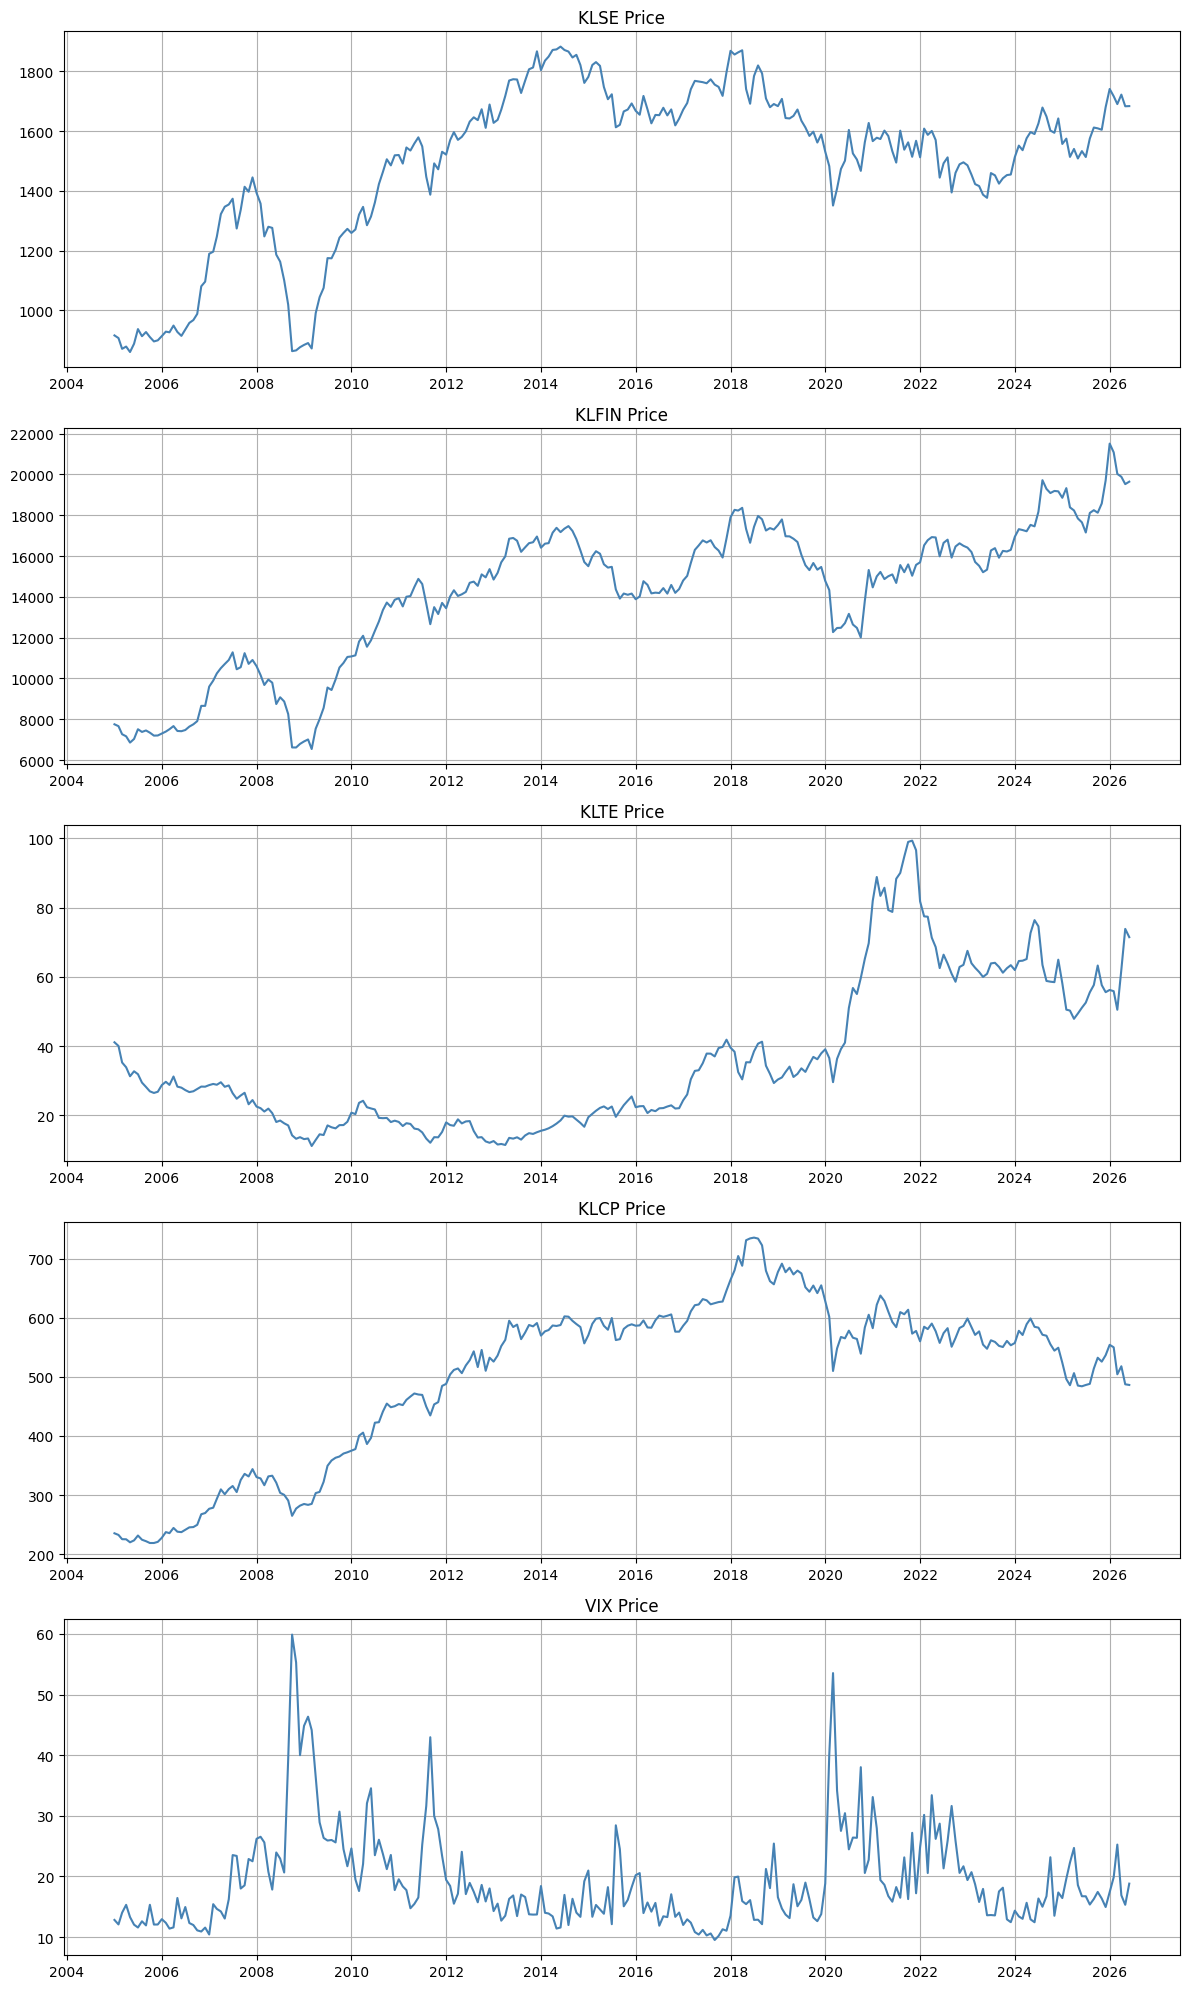

In [ ]:
# Investigating the large standard deviation

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

names = list(dataframe.keys())  # klse, klfin, klte, klcp, vix

fig, axes = plt.subplots(len(names), 1, figsize=(12, 4*len(names)))

for i, name in enumerate(names):
    axes[i].plot(combined['Date'], combined[f'{name}_price'], color='steelblue')
    axes[i].set_title(f"{name.upper()} Price")
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Confirming apart from VIX, the others are non-stationary
from statsmodels.tsa.stattools import adfuller

for name in dataframe.keys():
    series = combined[f'{name}_price'].dropna()
    result = adfuller(series)
    print(f"{name.upper()} - ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"  -> {name.upper()} price series is likely NON-stationary\n")
    else:
        print(f"  -> {name.upper()} price series is likely stationary\n")

KLSE - ADF Statistic: -2.1222, p-value: 0.2357
  -> KLSE price series is likely NON-stationary

KLFIN - ADF Statistic: -1.4730, p-value: 0.5468
  -> KLFIN price series is likely NON-stationary

KLTE - ADF Statistic: -1.1429, p-value: 0.6977
  -> KLTE price series is likely NON-stationary

KLCP - ADF Statistic: -1.9534, p-value: 0.3074
  -> KLCP price series is likely NON-stationary

VIX - ADF Statistic: -5.4916, p-value: 0.0000
  -> VIX price series is likely stationary



In [ ]:
# First difference

for name in dataframe.keys():
    combined[f'{name} price_diff'] = combined[f'{name}_price'].diff()

combined.head()

,Date,klse_price,klfin_price,klte_price,klcp_price,vix_price,klse_price_diff,klfin_price_diff,klte_price_diff,klcp_price_diff,...,klseprice_diff,klfinprice_diff,klteprice_diff,klcpprice_diff,vixprice_diff,klse price_diff,klfin price_diff,klte price_diff,klcp price_diff,vix price_diff
0,2005-01-01,916.27,7752.57,41.11,235.18,12.82,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-02-01,907.38,7660.98,40.05,232.40,12.08,-8.89,-91.59,-1.06,-2.78,...,-8.89,-91.59,-1.06,-2.78,-0.74,-8.89,-91.59,-1.06,-2.78,-0.74
2,2005-03-01,871.35,7265.98,35.26,225.19,14.02,-36.03,-395.00,-4.79,-7.21,...,-36.03,-395.00,-4.79,-7.21,1.94,-36.03,-395.00,-4.79,-7.21,1.94
3,2005-04-01,878.96,7164.05,33.89,225.02,15.31,7.61,-101.93,-1.37,-0.17,...,7.61,-101.93,-1.37,-0.17,1.29,7.61,-101.93,-1.37,-0.17,1.29
4,2005-05-01,860.73,6856.50,31.29,219.91,13.29,-18.23,-307.55,-2.60,-5.11,...,-18.23,-307.55,-2.60,-5.11,-2.02,-18.23,-307.55,-2.60,-5.11,-2.02


In [ ]:
from statsmodels.tsa.stattools import adfuller

for name in dataframe.keys():
    series = combined[f'{name} price_diff'].dropna()
    result = adfuller(series)
    print(f"{name.upper()} (1st diff) - ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] > 0.05:
        print(f"  -> still NON-stationary\n")
    else:
        print(f"  -> now stationary\n")

KLSE (1st diff) - ADF Statistic: -16.0848, p-value: 0.0000
  -> now stationary

KLFIN (1st diff) - ADF Statistic: -14.4325, p-value: 0.0000
  -> now stationary

KLTE (1st diff) - ADF Statistic: -8.2408, p-value: 0.0000
  -> now stationary

KLCP (1st diff) - ADF Statistic: -16.8432, p-value: 0.0000
  -> now stationary

VIX (1st diff) - ADF Statistic: -9.3167, p-value: 0.0000
  -> now stationary



In [ ]:
#Statistical summary of the new first differenced data
for name in dataframe.keys():
    print(f"=== {name} ===")
    print(combined[f'{name}_price_diff'].describe())
    print()


=== klse ===
count    257.000000
mean       2.985837
std       46.620377
min     -155.070000
25%      -24.270000
50%        7.490000
75%       29.810000
max      118.190000
Name: klse_price_diff, dtype: float64

=== klfin ===
count     257.000000
mean       46.271556
std       508.509952
min     -2059.980000
25%      -240.300000
50%        80.910000
75%       329.670000
max      1806.830000
Name: klfin_price_diff, dtype: float64

=== klte ===
count    257.000000
mean       0.118171
std        3.086995
min      -14.800000
25%       -1.190000
50%        0.100000
75%        1.370000
max       12.240000
Name: klte_price_diff, dtype: float64

=== klcp ===
count    257.000000
mean       0.977782
std       16.001975
min      -91.640000
25%       -6.970000
50%        1.970000
75%       10.430000
max       44.490000
Name: klcp_price_diff, dtype: float64

=== vix ===
count    257.000000
mean       0.023307
std        5.182181
min      -19.390000
25%       -2.350000
50%       -0.330000
75%       

/tmp/ipykernel_902/4287181026.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


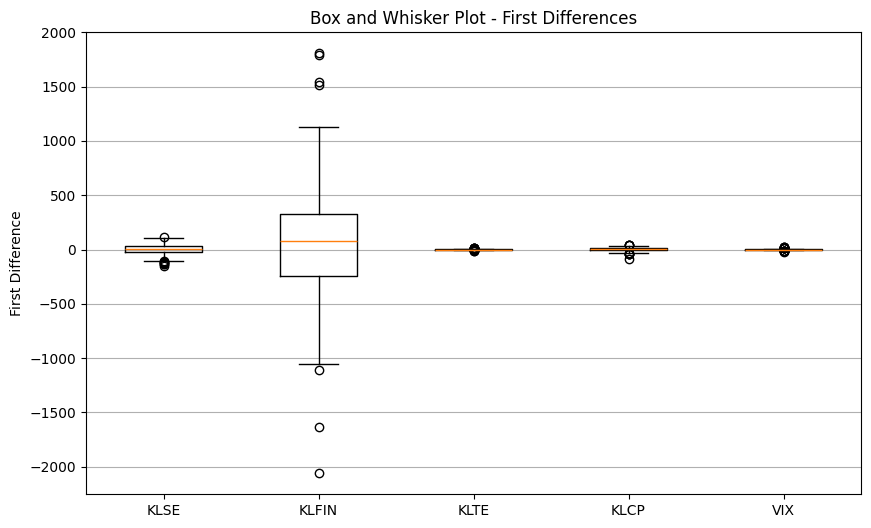

In [ ]:
import matplotlib.pyplot as plt

names = list(dataframe.keys())
cols = [f'{name}_price_diff' for name in names]

data = [combined[col].dropna() for col in cols]
labels = [name.upper() for name in names]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=labels)
plt.title("Box and Whisker Plot - First Differences")
plt.ylabel("First Difference")
plt.grid(True, axis='y')
plt.show()

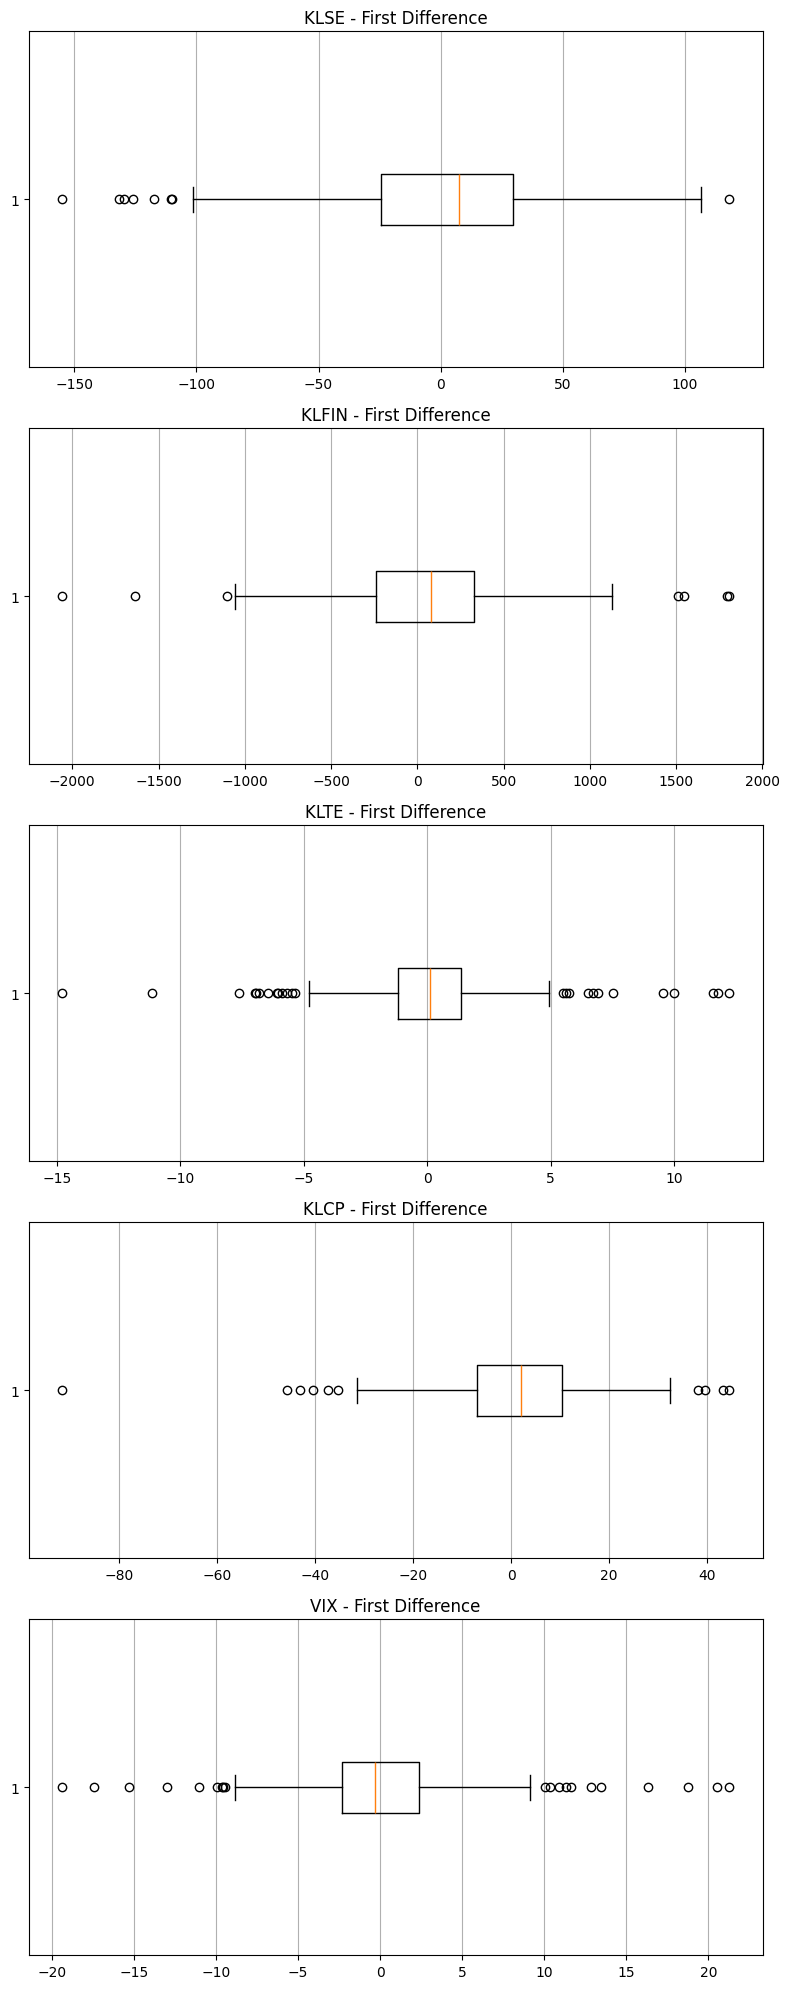

In [ ]:
import matplotlib.pyplot as plt

names = list(dataframe.keys())

fig, axes = plt.subplots(len(names), 1, figsize=(8, 4*len(names)))

for i, name in enumerate(names):
    col = f'{name}_price_diff'
    axes[i].boxplot(combined[col].dropna(), vert=False)
    axes[i].set_title(f"{name.upper()} - First Difference")
    axes[i].grid(True, axis='x')

plt.tight_layout()
plt.show()

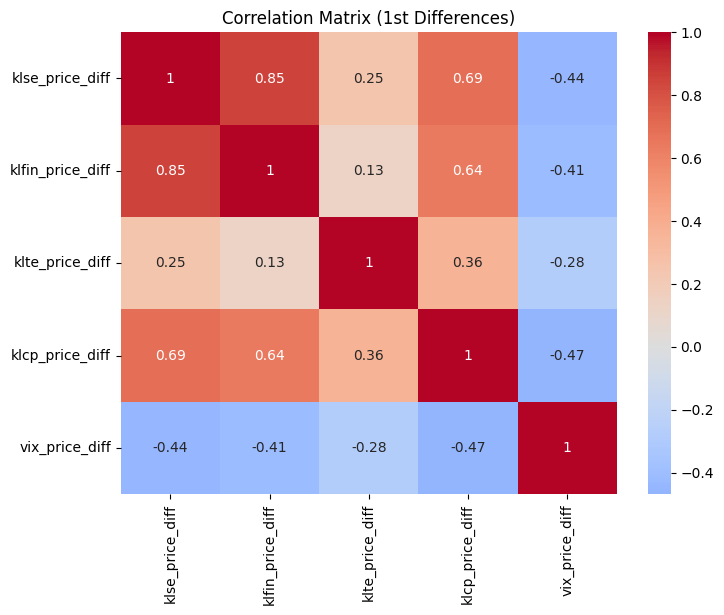

In [ ]:
#doing correlations with VIX

import seaborn as sns

cols = [f'{name}_price_diff' for name in dataframe.keys()]
corr_matrix = combined[cols].dropna().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (1st Differences)")
plt.show()

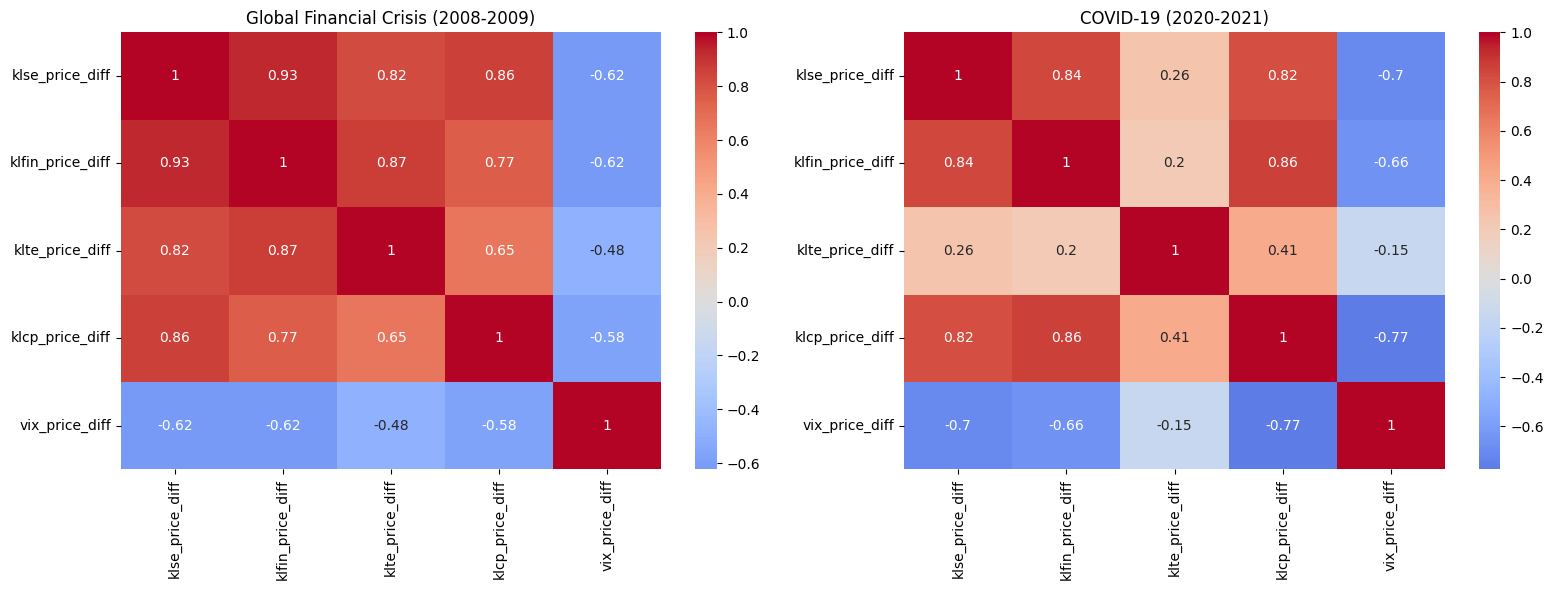

In [ ]:
#Correlation during crisis period

import seaborn as sns
import matplotlib.pyplot as plt

cols = [f'{name}_price_diff' for name in dataframe.keys()]

# Define your crisis periods
periods = {
    "Global Financial Crisis (2008-2009)": ("2008-01-01", "2009-12-31"),
    "COVID-19 (2020-2021)": ("2020-01-01", "2021-12-31")
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, (start, end)) in enumerate(periods.items()):
    mask = (combined['Date'] >= start) & (combined['Date'] <= end)
    subset = combined.loc[mask, cols].dropna()
    corr_matrix = subset.corr()

    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[i])
    axes[i].set_title(label)

plt.tight_layout()
plt.show()

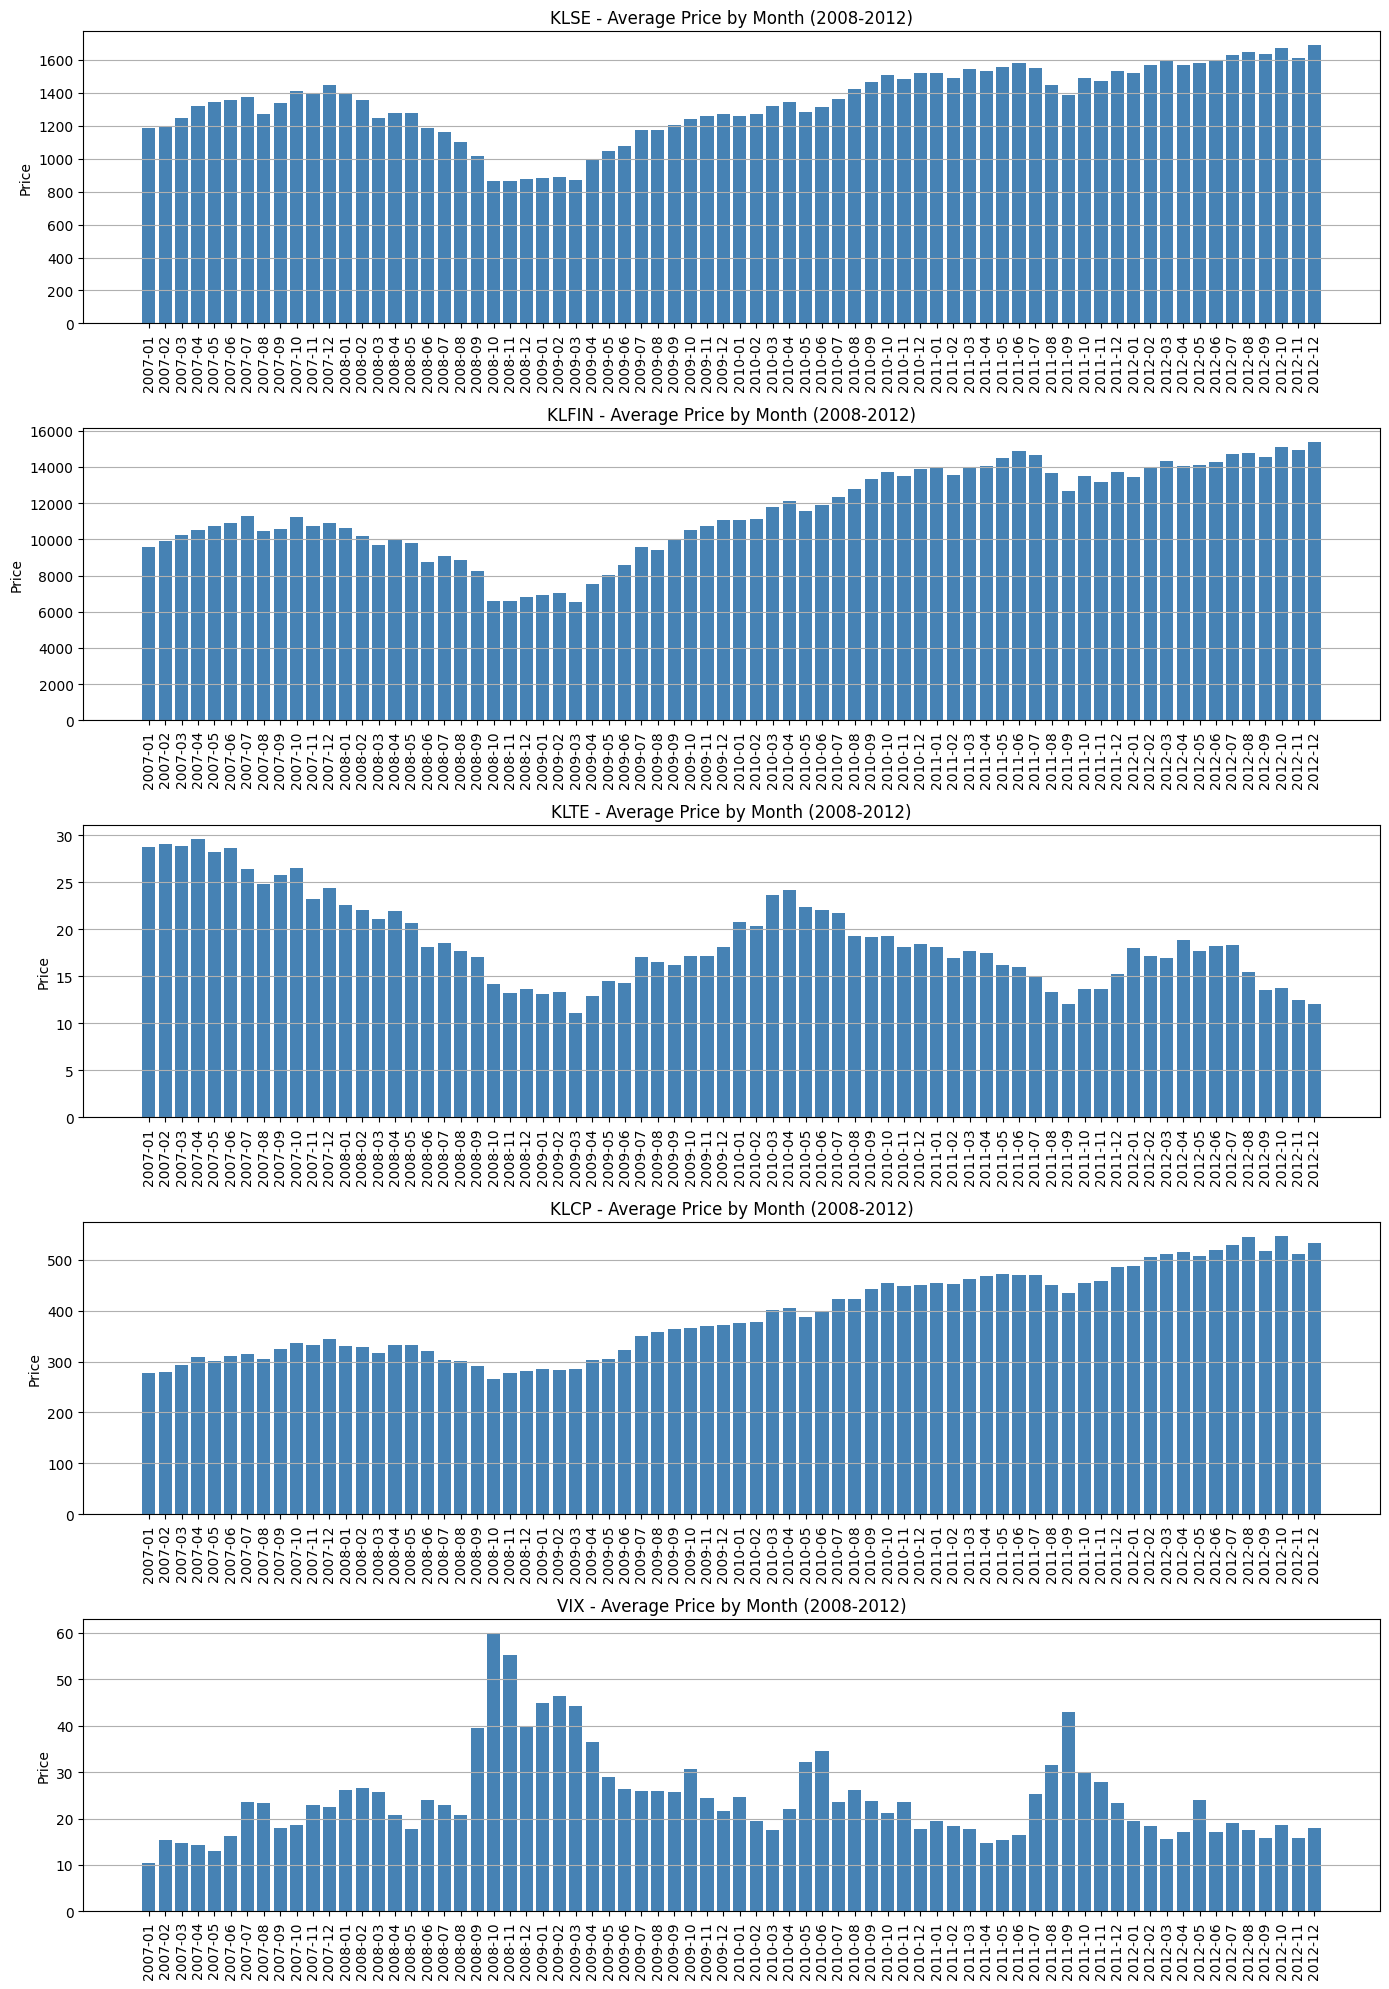

In [ ]:
# Trend post GFC
import matplotlib.pyplot as plt
import pandas as pd

names = list(dataframe.keys())

gfc_mask = combined['Date'].dt.year.isin([2007,2008, 2009, 2010, 2011, 2012])
gfc_data = combined.loc[gfc_mask].copy()
gfc_data['YearMonth'] = gfc_data['Date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(len(names), 1, figsize=(14, 4*len(names)))

for i, name in enumerate(names):
    col = f'{name}_price'
    monthly = gfc_data.groupby('YearMonth')[col].mean()

    axes[i].bar(monthly.index, monthly.values, color='steelblue')
    axes[i].set_title(f"{name.upper()} - Average Price by Month (2008-2012)")
    axes[i].set_ylabel("Price")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

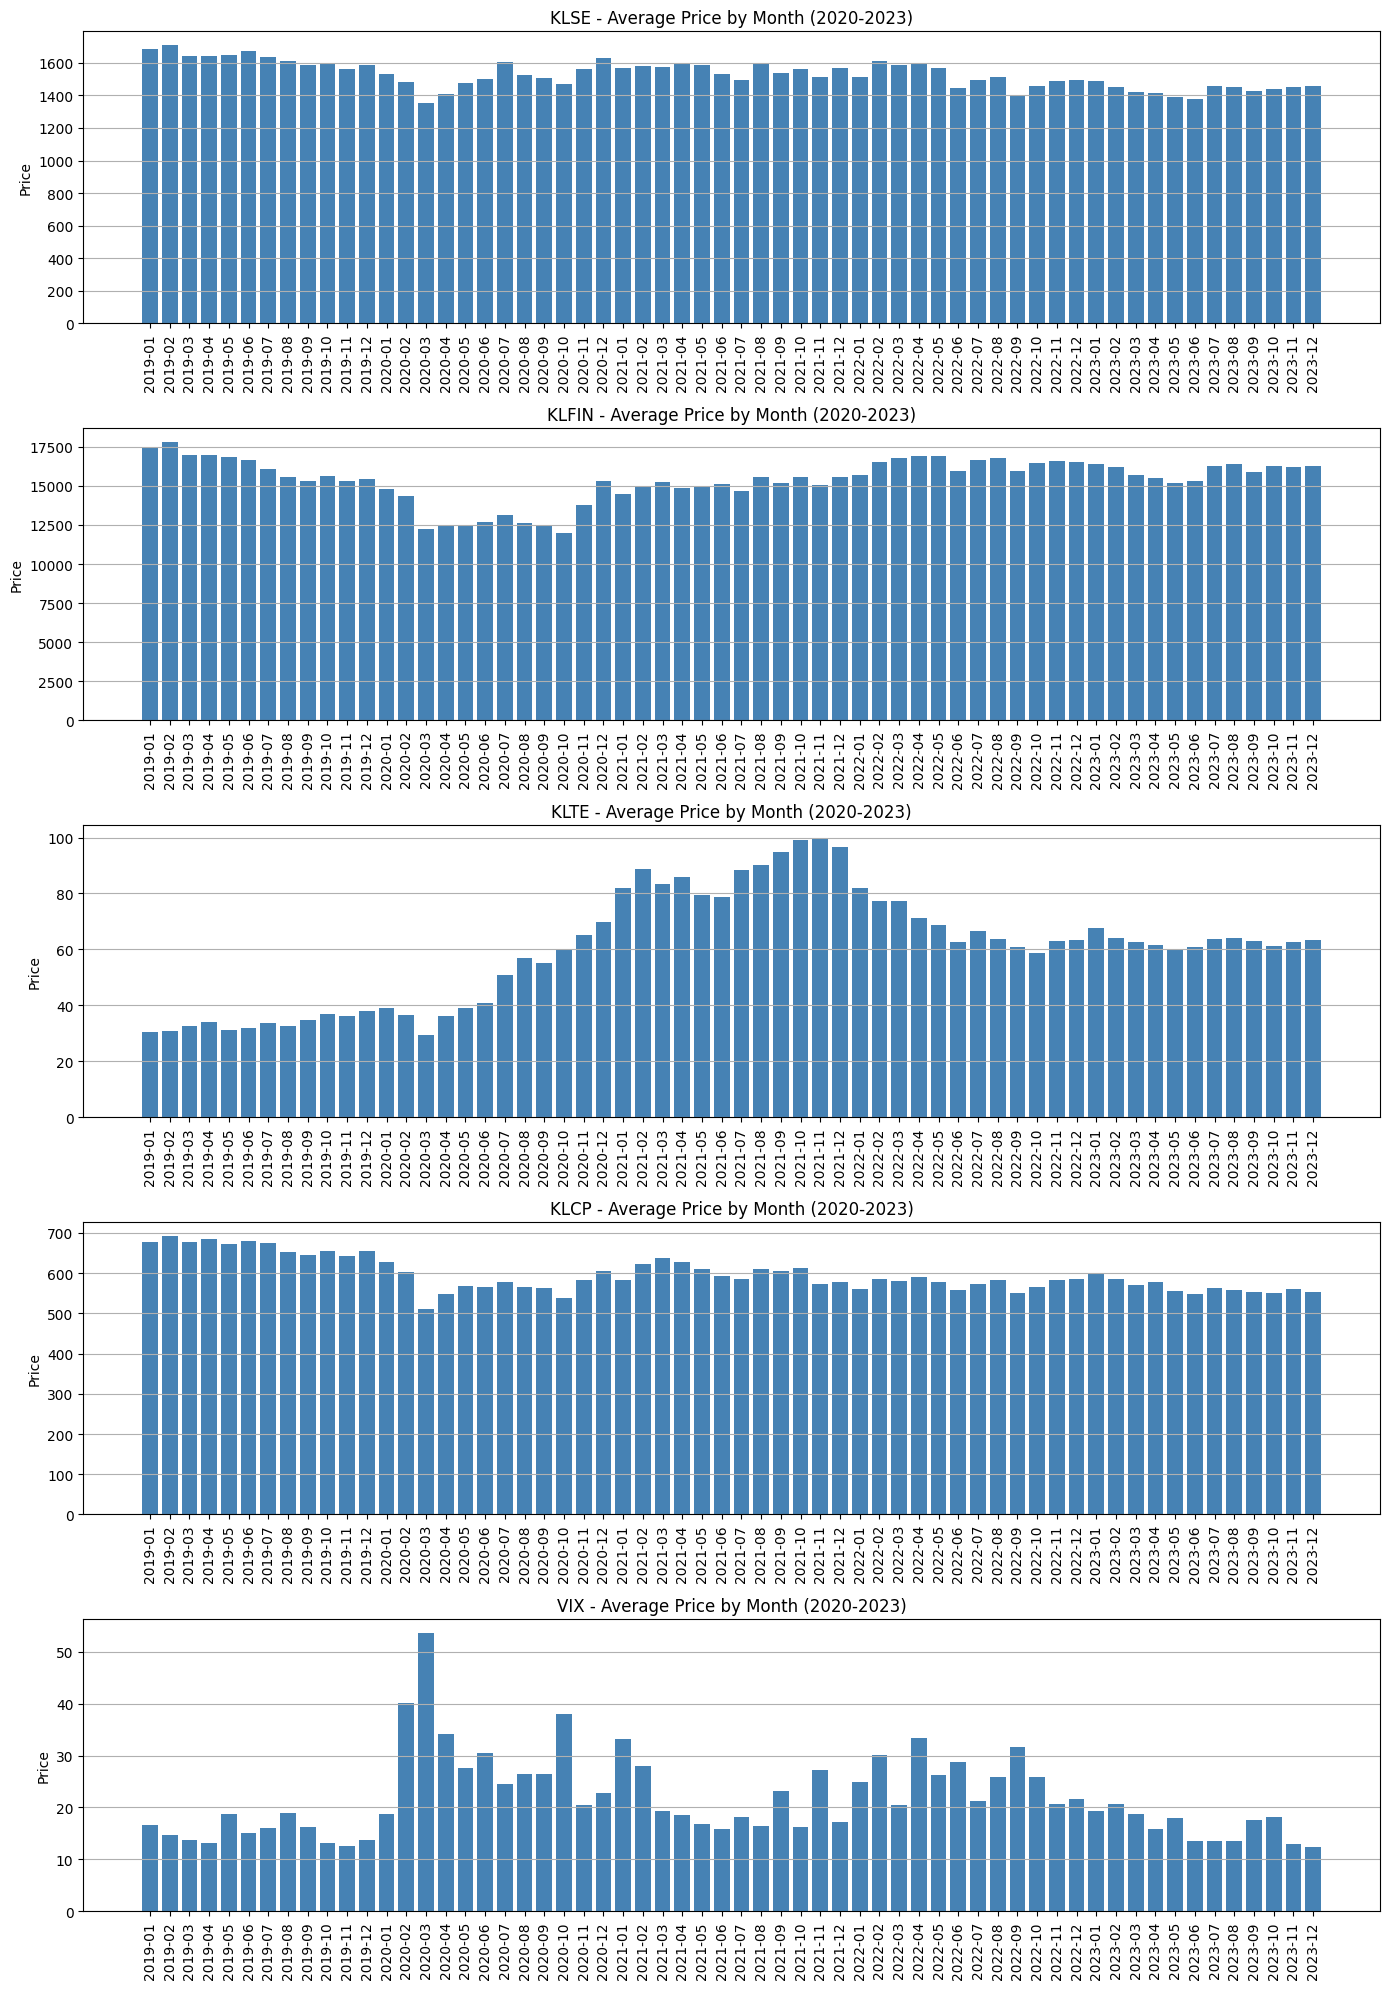

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

names = list(dataframe.keys())

covid_mask = combined['Date'].dt.year.isin([2019, 2020, 2021, 2022, 2023])
covid_data = combined.loc[covid_mask].copy()
covid_data['YearMonth'] = covid_data['Date'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(len(names), 1, figsize=(14, 4*len(names)))

for i, name in enumerate(names):
    col = f'{name}_price'
    monthly = covid_data.groupby('YearMonth')[col].mean()

    axes[i].bar(monthly.index, monthly.values, color='steelblue')
    axes[i].set_title(f"{name.upper()} - Average Price by Month (2020-2023)")
    axes[i].set_ylabel("Price")
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
#OLS for VIX and indicators

import statsmodels.api as sm
import pandas as pd

names = [n for n in dataframe.keys() if n != "vix"]

results = []
for name in names:
    df = combined[['vix_price', f'{name}_price_diff']].dropna()
    X = sm.add_constant(df['vix_price'])
    y = df[f'{name}_price_diff']
    model = sm.OLS(y, X).fit()
    results.append({
        'Index': name.upper(),
        'Coef (VIX)': model.params['vix_price'],
        'p-value': model.pvalues['vix_price'],
        'R-squared': model.rsquared
    })
    print(f"=== {name.upper()} ~ VIX ===")
    print(model.summary())
    print("\n")

pd.DataFrame(results)

=== KLSE ~ VIX ===
                            OLS Regression Results                            
Dep. Variable:        klse_price_diff   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     15.82
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           9.07e-05
Time:                        16:37:02   Log-Likelihood:                -1343.8
No. Observations:                 257   AIC:                             2692.
Df Residuals:                     255   BIC:                             2699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0874      7.377 

,Index,Coef (VIX),p-value,R-squared
0,KLSE,-1.407705,0.000091,0.058425
1,KLFIN,-17.490671,0.000007,0.075813
2,KLTE,-0.048780,0.042754,0.016001
3,KLCP,-0.410122,0.000939,0.042093


In [ ]:
#Causality tests
from statsmodels.tsa.stattools import grangercausalitytests

for name in names:
    df = combined[['vix_price_diff', f'{name}_price_diff']].dropna()
    print(f"=== VIX -> {name.upper()} ===")
    grangercausalitytests(df[['vix_price_diff', f'{name}_price_diff']], maxlag=4)

=== VIX -> KLSE ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0770  , p=0.7816  , df_denom=253, df_num=1
ssr based chi2 test:   chi2=0.0779  , p=0.7801  , df=1
likelihood ratio test: chi2=0.0779  , p=0.7802  , df=1
parameter F test:         F=0.0770  , p=0.7816  , df_denom=253, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.3639  , p=0.0962  , df_denom=250, df_num=2
ssr based chi2 test:   chi2=4.8223  , p=0.0897  , df=2
likelihood ratio test: chi2=4.7773  , p=0.0918  , df=2
parameter F test:         F=2.3639  , p=0.0962  , df_denom=250, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2405  , p=0.2956  , df_denom=247, df_num=3
ssr based chi2 test:   chi2=3.8269  , p=0.2808  , df=3
likelihood ratio test: chi2=3.7983  , p=0.2841  , df=3
parameter F test:         F=1.2405  , p=0.2956  , df_denom=247, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=